In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os

mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- PDF structure: keep elements separate ---
    'pdf.compression': 0,         # prevents grouping/merging of vector paths
    'savefig.transparent': True,  # optional: preserves transparent backgrounds
    'savefig.bbox': 'tight',      # trims whitespace
    'savefig.pad_inches': 0.02,   # small padding for Illustrator bleed safety

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [17]:
p18_data = pd.read_csv('../Data/P18_coverage_info.csv')
p18_data['patient_alias'] = 'P18'

p17_data = pd.read_csv('../Data/P17_coverage_info.csv')
p17_data['patient_alias'] = 'P17'

p03_data = pd.read_csv('../Data/P03_coverage_info.csv')
p03_data['patient_alias'] = 'P03'

print(p03_data.shape[0])
print(p17_data.shape[0])
print(p18_data.shape[0])
print(p03_data.shape[0] + p17_data.shape[0] + p18_data.shape[0])

8009
8300
8243
24552


In [19]:
df_all = pd.concat([p03_data, p17_data, p18_data])

In [21]:
df_all

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,name,included_SNPmanifold,median,mean,max,min,IQR,patient_alias
0,chrM,4,.,C,N,.,PASS,AD=1;DP=190;OTH=0,4C>N,False,0.0,0.032096,3,0,0.0,P03
1,chrM,5,.,A,C,.,PASS,AD=1;DP=207;OTH=0,5A>C,False,0.0,0.035242,3,0,0.0,P03
2,chrM,6,.,C,A,.,PASS,AD=1;DP=230;OTH=0,6C>A,False,0.0,0.039438,3,0,0.0,P03
3,chrM,7,.,A,C,.,PASS,AD=1;DP=234;OTH=0,7A>C,False,0.0,0.039857,3,0,0.0,P03
4,chrM,8,.,G,T,.,PASS,AD=1;DP=285;OTH=0,8G>T,False,0.0,0.046780,3,0,0.0,P03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8238,chrM,16558,.,G,T,.,PASS,AD=2;DP=1401;OTH=0,16558G>T,False,0.0,0.174776,4,0,0.0,P18
8239,chrM,16561,.,A,C,.,PASS,AD=2;DP=1280;OTH=2,16561A>C,False,0.0,0.161931,3,0,0.0,P18
8240,chrM,16562,.,T,C,.,PASS,AD=3;DP=1268;OTH=2,16562T>C,False,0.0,0.160958,3,0,0.0,P18
8241,chrM,16565,.,C,T,.,PASS,AD=2;DP=1177;OTH=1,16565C>T,False,0.0,0.151032,3,0,0.0,P18


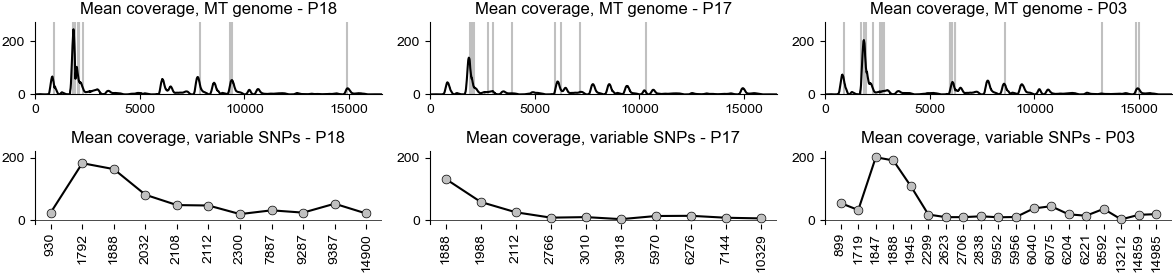

In [175]:
fig, ax = plt.subplots(2, 3, figsize = (12, 3))
ax = ax.ravel()

for i, p in enumerate(['P18', 'P17', 'P03']):
    data = df_all.loc[df_all['patient_alias']==p]
    x = data['POS']
    y = data['mean']
    ax[i].plot(x, y, color = 'k')
    ax[i].set_ylim(0, 270)
    ax[i].set_xlim(0, 16567)
    ax[i].set_xticks(np.arange(0, 17000, 5000))
    ax[i].set_title(f'Mean coverage, MT genome - {p}')
    for d in ['top', 'right']:
        ax[i].spines[d].set_visible(False)

for i, p in enumerate(['P18', 'P17', 'P03']):
    j = i + 3
    data = df_all.loc[(df_all['patient_alias']==p) & (df_all['included_SNPmanifold']==True)].reset_index()
    n = data.shape[0]
    x = data.index
    y = data['mean']
    ax[j].plot(x, y, color = 'k', zorder=0)
    ax[j].scatter(x, y, color = 'silver', marker = 'o', s = 40, edgecolor='k', linewidth = 0.5)
    ax[j].set_ylim(-10, 220)
    ax[j].set_xticks(np.arange(0, n, 1))
    ax[j].set_xticklabels(data['POS'], rotation=90)
    ax[j].set_title(f'Mean coverage, variable SNPs - {p}')
    ax[j].axhline(y=0, zorder=0, color = 'k', linewidth = 0.5)
    for d in ['top', 'right', 'bottom']:
        ax[j].spines[d].set_visible(False)

    for k in data['POS'].to_list():
        ax[i].axvline(x = k, color='silver', zorder=0)

fig.tight_layout()
fig.savefig('../Figures/5_MT_coverage_plots_v1.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

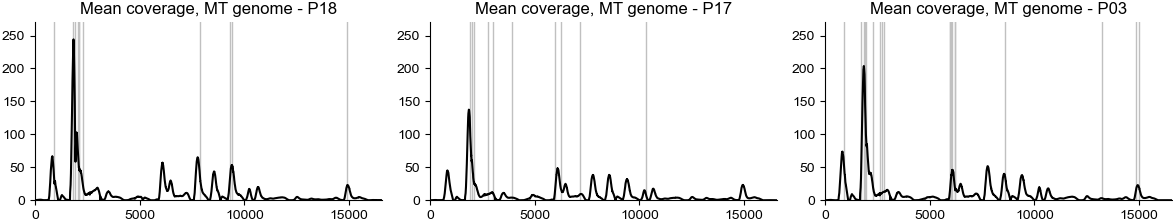

In [183]:
#Just the upper plot
fig, ax = plt.subplots(1, 3, figsize = (12, 2.5))

for i, p in enumerate(['P18', 'P17', 'P03']):
    data = df_all.loc[df_all['patient_alias']==p]
    x = data['POS']
    y = data['mean']
    ax[i].plot(x, y, color = 'k')
    ax[i].set_ylim(0, 270)
    ax[i].set_xlim(0, 16567)
    ax[i].set_xticks(np.arange(0, 17000, 5000))
    ax[i].set_title(f'Mean coverage, MT genome - {p}')
    for d in ['top', 'right']:
        ax[i].spines[d].set_visible(False)

for i, p in enumerate(['P18', 'P17', 'P03']):
    #j = i + 3
    data = df_all.loc[(df_all['patient_alias']==p) & (df_all['included_SNPmanifold']==True)].reset_index()
    # n = data.shape[0]
    # x = data.index
    # y = data['mean']
    # ax[j].plot(x, y, color = 'k', zorder=0)
    # #ax[j].scatter(x, y, color = 'silver', marker = 'o', s = 40, edgecolor='k', linewidth = 0.5)
    # ax[j].set_ylim(-10, 220)
    # ax[j].set_xticks(np.arange(0, n, 1))
    # ax[j].set_xticklabels(data['POS'], rotation=90)
    # ax[j].set_title(f'Mean coverage, variable SNPs - {p}')
    # ax[j].axhline(y=0, zorder=0, color = 'k', linewidth = 0.5)
    # for d in ['top', 'right', 'bottom']:
    #     ax[j].spines[d].set_visible(False)

    for k in data['POS'].to_list():
        ax[i].axvline(x = k, color='silver', zorder=0, linewidth = 1)

fig.tight_layout()
fig.savefig('../Figures/5_MT_coverage_plots_whole_genome_v1.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)